# NB4 — RGB CNN Training (MobileNetV3 + NTHU-DDD)

**Prerequisites:** `NB1_Setup_and_Data.ipynb` must have been run (NTHU-DDD cached to Drive).

**Steps:**
1. Install packages
2. Mount Drive & configure paths
3. Restore NTHU-DDD dataset to local SSD
4. Build RGB CNN (MobileNetV3Small, binary classification)
5. Load NTHU-DDD images with `tf.data` pipeline
6. Phase 1 — train head only (frozen backbone, lr=1e-3)
7. Phase 2 — fine-tune last 5 backbone layers (lr=1e-6)
8. Auto-select the better of Phase 1 / Phase 2
9. Evaluate on test set

> Saves `rgb_cnn.h5` to `MyDrive/drowsiness/models/`

---

In [1]:
# Install packages (run once per Colab session)
!pip install -q kagglehub mediapipe opencv-python-headless \
    pygame imbalanced-learn tqdm seaborn "protobuf>=5.26.1,<6.0.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 6.0 MB/s eta 0:00:00


In [2]:
# Common imports
import os, shutil, tarfile, time, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV3Small
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score, f1_score)

np.random.seed(42)
tf.random.set_seed(42)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print('GPU:', gpus[0].name)
else:
    print('WARNING: No GPU — go to Runtime > Change runtime type > T4 GPU')
print('TensorFlow:', tf.__version__)


GPU: /physical_device:GPU:0
TensorFlow: 2.19.0


In [3]:
# Mount Google Drive and configure paths
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT    = '/content/drive/MyDrive/drowsiness'
MODEL_DIR     = DRIVE_ROOT + '/models'
DATASET_DIR   = DRIVE_ROOT + '/datasets'
LOCAL_DS_ROOT = '/content/datasets'

for d in [MODEL_DIR, DATASET_DIR, LOCAL_DS_ROOT]:
    os.makedirs(d, exist_ok=True)

nthu_path         = os.path.join(LOCAL_DS_ROOT, 'nthu_ddd')
RGB_MODEL_PATH    = os.path.join(MODEL_DIR, 'rgb_cnn.h5')
PHASE1_BEST_PATH  = '/content/rgb_phase1_best.keras'
EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

print('Model dir  :', MODEL_DIR)
print('Dataset dir:', LOCAL_DS_ROOT)


Mounted at /content/drive
Model dir  : /content/drive/MyDrive/drowsiness/models
Dataset dir: /content/datasets


In [4]:
# Restore NTHU-DDD from Drive archive to local SSD (fast on session restart)
archive = os.path.join(DATASET_DIR, 'nthu_ddd.tar.gz')

if os.path.isdir(nthu_path) and any(os.scandir(nthu_path)):
    print('[OK] NTHU-DDD already on local SSD')
elif os.path.isfile(archive):
    print('Extracting NTHU-DDD from Drive ...')
    os.makedirs(nthu_path, exist_ok=True)
    with tarfile.open(archive, 'r:gz') as tar:
        tar.extractall(nthu_path)
    print('Done ->', nthu_path)
else:
    print('[ERROR] nthu_ddd.tar.gz not found on Drive.')
    print('        Run NB1_Setup_and_Data.ipynb first to download datasets.')


Extracting NTHU-DDD from Drive ...


/tmp/ipykernel_609/1432467883.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(nthu_path)


Done -> /content/datasets/nthu_ddd


In [5]:
# Build RGB CNN (MobileNetV3Small, binary: 0=Non-Drowsy, 1=Drowsy)
# num_classes is fixed at 2 — do NOT change unless you have 3-class labels.

def build_rgb_cnn(input_shape=(224, 224, 3), num_classes=2):
    base = MobileNetV3Small(
        input_shape=input_shape, include_top=False, weights='imagenet')
    base.trainable = False

    inp  = keras.Input(shape=input_shape, name='rgb_input')
    x    = base(inp, training=False)           # frozen BN uses running stats
    x    = layers.GlobalAveragePooling2D(name='gap')(x)
    feat = layers.Dense(
        256, activation='relu',
        kernel_regularizer=keras.regularizers.l2(1e-4),
        name='rgb_features',
    )(x)
    x    = layers.BatchNormalization(name='bn_head')(feat)
    x    = layers.Dropout(0.5, name='dropout_head')(x)
    out  = layers.Dense(num_classes, activation='softmax',
                        name='drowsiness_class')(x)

    model = keras.Model(inp, out, name='RGB_CNN')
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


rgb_model = build_rgb_cnn(num_classes=2)
print('Built RGB CNN — 2 output classes (Non-Drowsy / Drowsy)')
rgb_model.summary()


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Built RGB CNN — 2 output classes (Non-Drowsy / Drowsy)


Model: "RGB_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rgb_features (Dense)            │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_head (BatchNormalization)    │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_head (Dropout)          │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drowsiness_class (Dense)        │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,088,370 (4.15 MB)

 Trainable params: 148,738 (581.01 KB)

 Non-trainable params: 939,632 (3.58 MB)

In [6]:
# Load NTHU-DDD images into tf.data datasets
# Uses tf.data instead of ImageDataGenerator — fixes Keras 3.x validation
# instability (ImageDataGenerator's index reset bug causes loss to oscillate).

nthu_face_root = os.path.join(nthu_path, 'Driver Drowsiness Dataset (DDD)')
print('NTHU-DDD face root:', nthu_face_root)

# Collect file paths + integer labels (0=Non-Drowsy, 1=Drowsy)
NOT_DROWSY_KEYS = ('non drowsy', 'not drowsy', 'notdrowsy', 'non_drowsy',
                   'not_drowsy', 'nondrowsy', 'normal', 'alert')
rgb_records = []
for p in Path(nthu_face_root).rglob('*'):
    if p.suffix.lower() not in EXTS:
        continue
    folder = p.parent.name.lower()
    if any(folder == k or folder.startswith(k) for k in NOT_DROWSY_KEYS):
        lbl = 0
    elif 'drowsy' in folder:
        lbl = 1
    else:
        continue
    rgb_records.append({'path': str(p), 'label': lbl})

df_rgb = pd.DataFrame(rgb_records)
print(f'Total images : {len(df_rgb):,}')
print(df_rgb['label'].value_counts().sort_index()
      .rename({0: 'Non-Drowsy', 1: 'Drowsy'}))

# Stratified 70 / 15 / 15 split
df_tv, df_test = train_test_split(
    df_rgb, test_size=0.15, random_state=42, stratify=df_rgb['label'])
df_train, df_val = train_test_split(
    df_tv, test_size=0.15 / 0.85, random_state=42, stratify=df_tv['label'])
for d in [df_train, df_val, df_test]:
    d.reset_index(drop=True, inplace=True)
print(f'Train: {len(df_train)}  Val: {len(df_val)}  Test: {len(df_test)}')

# ── tf.data image loading ────────────────────────────────────────────────────
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE
IMG_SIZE   = 224

def load_img(path, label, augment=False):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img / 255.0
    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.30)
        img = tf.image.random_contrast(img, lower=0.70, upper=1.30)
        img = tf.image.random_saturation(img, lower=0.80, upper=1.20)
        img = tf.image.resize_with_crop_or_pad(img, 240, 240)
        img = tf.image.random_crop(img, [IMG_SIZE, IMG_SIZE, 3])
        img = tf.clip_by_value(img, 0.0, 1.0)
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    return img, label

def make_ds(df, augment=False, shuffle=False):
    paths  = tf.constant(df['path'].values)
    labels = tf.constant(df['label'].astype(np.int32).values)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(df), seed=42, reshuffle_each_iteration=True)
    ds = (ds
          .map(lambda p, l: load_img(p, l, augment=augment),
               num_parallel_calls=AUTOTUNE)
          .batch(BATCH_SIZE)
          .prefetch(AUTOTUNE))
    return ds

rgb_train_ds = make_ds(df_train, augment=True,  shuffle=True)
rgb_val_ds   = make_ds(df_val,   augment=False, shuffle=False)
rgb_test_ds  = make_ds(df_test,  augment=False, shuffle=False)

y_arr  = df_train['label'].values
cw     = compute_class_weight('balanced', classes=np.unique(y_arr), y=y_arr)
rgb_cw = {int(c): float(w) for c, w in zip(np.unique(y_arr), cw)}
print('Class weights :', rgb_cw)
print(f'Train batches : {len(rgb_train_ds)} | '
      f'Val : {len(rgb_val_ds)} | Test : {len(rgb_test_ds)}')


NTHU-DDD face root: /content/datasets/nthu_ddd/Driver Drowsiness Dataset (DDD)
Total images : 41,793
label
Non-Drowsy    19445
Drowsy        22348
Name: count, dtype: int64
Train: 29255  Val: 6269  Test: 6269
Class weights : {0: 1.0746822423040188, 1: 0.9350230120173869}
Train batches : 915 | Val : 196 | Test : 196


In [7]:
# Two-phase transfer learning
# Phase 1 — train head only (backbone frozen, lr=1e-3)
# Phase 2 — fine-tune last 5 backbone layers (lr=1e-6)
# At the end, automatically reloads Phase 1 if it was better than Phase 2.

# ── Phase 1 ──────────────────────────────────────────────────────────────────
rgb_cbs1 = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=6,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint(
        RGB_MODEL_PATH, monitor='val_loss',
        save_best_only=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-7, verbose=1),
]

print('=== PHASE 1: Frozen backbone — training head only ===')
rgb_history1 = rgb_model.fit(
    rgb_train_ds, validation_data=rgb_val_ds,
    epochs=20, callbacks=rgb_cbs1, class_weight=rgb_cw, verbose=1,
)
p1_best = min(rgb_history1.history['val_loss'])
p1_best_acc = max(rgb_history1.history['val_accuracy'])
print(f'Phase 1 best  val_loss={p1_best:.4f}  val_accuracy={p1_best_acc:.4f}')

# Persist Phase-1 best weights (EarlyStopping already restored them in-memory)
rgb_model.save(PHASE1_BEST_PATH)
phase1_weights = rgb_model.get_weights()

# ── Phase 2 ──────────────────────────────────────────────────────────────────
base = rgb_model.layers[1]          # MobileNetV3Small sub-model
base.trainable = True
for layer in base.layers[:-5]:      # unfreeze only last 5 layers
    layer.trainable = False
n_unfrozen = sum(1 for l in base.layers if l.trainable)
print(f'Unfreezing {n_unfrozen} backbone layers (last 5)')

# Recompile with lower LR, then restore Phase-1 weights.
# Restoring AFTER compile prevents the catastrophic val_loss spike that
# occurs when a freshly compiled Adam optimizer encounters previously frozen
# backbone weights for the first time.
rgb_model.compile(
    optimizer=keras.optimizers.Adam(1e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
rgb_model.set_weights(phase1_weights)   # ← prevents Phase-2 explosion

rgb_cbs2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint(
        RGB_MODEL_PATH, monitor='val_loss',
        save_best_only=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-9, verbose=1),
]

print('=== PHASE 2: Fine-tuning last 5 backbone layers ===')
rgb_history2 = rgb_model.fit(
    rgb_train_ds, validation_data=rgb_val_ds,
    epochs=20, callbacks=rgb_cbs2, class_weight=rgb_cw, verbose=1,
)
p2_best = min(rgb_history2.history['val_loss'])
p2_best_acc = max(rgb_history2.history['val_accuracy'])
print(f'Phase 2 best  val_loss={p2_best:.4f}  val_accuracy={p2_best_acc:.4f}')

# ── Keep the better model ────────────────────────────────────────────────────
if p1_best <= p2_best:
    print(f'Phase 1 was better ({p1_best:.4f} <= {p2_best:.4f}) — reloading Phase-1 best')
    rgb_model = keras.models.load_model(PHASE1_BEST_PATH)
    rgb_model.save(RGB_MODEL_PATH)          # overwrite Drive checkpoint
    print(f'Final model = Phase 1  (val_acc={p1_best_acc:.4f})')
else:
    print(f'Phase 2 improved ({p2_best:.4f} < {p1_best:.4f}) — keeping Phase-2 best')
    print(f'Final model = Phase 2  (val_acc={p2_best_acc:.4f})')

print(f'Saved to {RGB_MODEL_PATH}')


=== PHASE 1: Frozen backbone — training head only ===
Epoch 1/20
915/915 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.6208 - loss: 0.6666
Epoch 1: val_loss improved from inf to 5.89787, saving model to /content/drive/MyDrive/drowsiness/models/rgb_cnn.h5


915/915 ━━━━━━━━━━━━━━━━━━━━ 170s 167ms/step - accuracy: 0.6209 - loss: 0.6665 - val_accuracy: 0.5347 - val_loss: 5.8979 - learning_rate: 0.0010
Epoch 2/20
914/915 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.7248 - loss: 0.5679
Epoch 2: val_loss improved from 5.89787 to 4.49614, saving model to /content/drive/MyDrive/drowsiness/models/rgb_cnn.h5


915/915 ━━━━━━━━━━━━━━━━━━━━ 107s 117ms/step - accuracy: 0.7249 - loss: 0.5679 - val_accuracy: 0.5347 - val_loss: 4.4961 - learning_rate: 0.0010
Epoch 3/20
914/915 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7432 - loss: 0.5416
Epoch 3: val_loss improved from 4.49614 to 4.15616, saving model to /content/drive/MyDrive/drowsiness/models/rgb_cnn.h5


915/915 ━━━━━━━━━━━━━━━━━━━━ 140s 115ms/step - accuracy: 0.7433 - loss: 0.5416 - val_accuracy: 0.5347 - val_loss: 4.1562 - learning_rate: 0.0010
Epoch 4/20
914/915 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.7643 - loss: 0.5157
Epoch 4: val_loss did not improve from 4.15616
915/915 ━━━━━━━━━━━━━━━━━━━━ 97s 106ms/step - accuracy: 0.7643 - loss: 0.5157 - val_accuracy: 0.4653 - val_loss: 5.2976 - learning_rate: 0.0010
Epoch 5/20
914/915 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.7751 - loss: 0.5022
Epoch 5: val_loss did not improve from 4.15616
915/915 ━━━━━━━━━━━━━━━━━━━━ 109s 119ms/step - accuracy: 0.7751 - loss: 0.5022 - val_accuracy: 0.4653 - val_loss: 8.2483 - learning_rate: 0.0010
Epoch 6/20
914/915 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.7815 - loss: 0.4895
Epoch 6: val_loss did not improve from 4.15616

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
915/915 ━━━━━━━━━━━━━━━━━━━━ 107s 117ms/step - accuracy: 0.7814 - loss: 0.4895 - val_a

915/915 ━━━━━━━━━━━━━━━━━━━━ 106s 116ms/step - accuracy: 0.7941 - loss: 0.4703 - val_accuracy: 0.5794 - val_loss: 0.8274 - learning_rate: 5.0000e-04
Epoch 8/20
914/915 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8082 - loss: 0.4454
Epoch 8: val_loss did not improve from 0.82739
915/915 ━━━━━━━━━━━━━━━━━━━━ 98s 107ms/step - accuracy: 0.8082 - loss: 0.4454 - val_accuracy: 0.5347 - val_loss: 7.4849 - learning_rate: 5.0000e-04
Epoch 9/20
914/915 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8072 - loss: 0.4460
Epoch 9: val_loss did not improve from 0.82739
915/915 ━━━━━━━━━━━━━━━━━━━━ 96s 105ms/step - accuracy: 0.8072 - loss: 0.4460 - val_accuracy: 0.5738 - val_loss: 0.9301 - learning_rate: 5.0000e-04
Epoch 10/20
914/915 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.8138 - loss: 0.4352
Epoch 10: val_loss improved from 0.82739 to 0.32032, saving model to /content/drive/MyDrive/drowsiness/models/rgb_cnn.h5


...

915/915 ━━━━━━━━━━━━━━━━━━━━ 134s 108ms/step - accuracy: 0.6339 - loss: 1.5392 - val_accuracy: 0.6441 - val_loss: 1.7151 - learning_rate: 5.0000e-07
Epoch 18/20
914/915 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.6247 - loss: 1.5523
Epoch 18: val_loss improved from 1.71509 to 1.70155, saving model to /content/drive/MyDrive/drowsiness/models/rgb_cnn.h5


915/915 ━━━━━━━━━━━━━━━━━━━━ 142s 108ms/step - accuracy: 0.6247 - loss: 1.5522 - val_accuracy: 0.6427 - val_loss: 1.7016 - learning_rate: 5.0000e-07
Epoch 19/20
914/915 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.6397 - loss: 1.4477
Epoch 19: val_loss did not improve from 1.70155
915/915 ━━━━━━━━━━━━━━━━━━━━ 98s 108ms/step - accuracy: 0.6397 - loss: 1.4477 - val_accuracy: 0.6306 - val_loss: 1.9401 - learning_rate: 5.0000e-07
Epoch 20/20
914/915 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.6338 - loss: 1.4559
Epoch 20: val_loss improved from 1.70155 to 1.60332, saving model to /content/drive/MyDrive/drowsiness/models/rgb_cnn.h5


915/915 ━━━━━━━━━━━━━━━━━━━━ 97s 106ms/step - accuracy: 0.6338 - loss: 1.4558 - val_accuracy: 0.6472 - val_loss: 1.6033 - learning_rate: 5.0000e-07
Restoring model weights from the end of the best epoch: 20.
Phase 2 best  val_loss=1.6033  val_accuracy=0.6472
Phase 1 was better (0.2598 <= 1.6033) — reloading Phase-1 best


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Final model = Phase 1  (val_acc=0.9073)
Saved to /content/drive/MyDrive/drowsiness/models/rgb_cnn.h5


196/196 ━━━━━━━━━━━━━━━━━━━━ 22s 87ms/step
Test samples : 6269
Test accuracy: 89.98%

              precision    recall  f1-score   support

  Non-Drowsy       0.95      0.83      0.88      2917
      Drowsy       0.87      0.96      0.91      3352

    accuracy                           0.90      6269
   macro avg       0.91      0.90      0.90      6269
weighted avg       0.90      0.90      0.90      6269



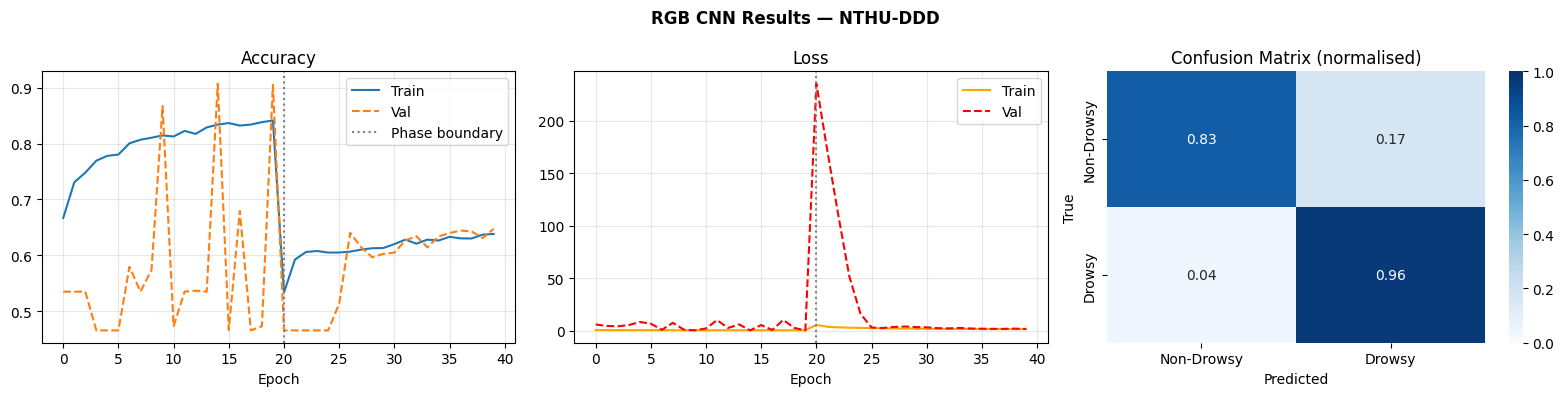

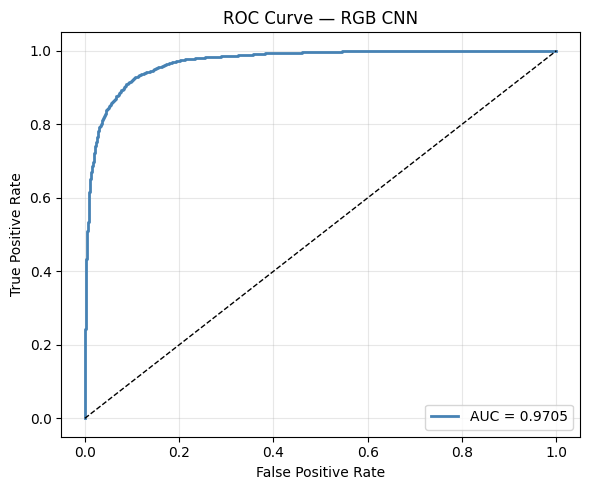

AUC-ROC: 0.9705


In [8]:
# Evaluate RGB CNN on held-out test set
y_true = np.concatenate([y.numpy() for _, y in rgb_test_ds], axis=0)
y_prob = rgb_model.predict(rgb_test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

CLASS_NAMES = ['Non-Drowsy', 'Drowsy']
print(f'Test samples : {len(y_true)}')
print(f'Test accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%')
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

# ── Plots ────────────────────────────────────────────────────────────────────
def cat(h1, h2, key):
    return h1.history.get(key, []) + h2.history.get(key, [])

p1_len = len(rgb_history1.history['accuracy'])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Accuracy
axes[0].plot(cat(rgb_history1, rgb_history2, 'accuracy'), label='Train')
axes[0].plot(cat(rgb_history1, rgb_history2, 'val_accuracy'),
             label='Val', linestyle='--')
axes[0].axvline(p1_len, color='gray', linestyle=':', label='Phase boundary')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('Epoch')

# Loss
axes[1].plot(cat(rgb_history1, rgb_history2, 'loss'),
             color='orange', label='Train')
axes[1].plot(cat(rgb_history1, rgb_history2, 'val_loss'),
             color='red', linestyle='--', label='Val')
axes[1].axvline(p1_len, color='gray', linestyle=':')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('Epoch')

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[2], vmin=0, vmax=1)
axes[2].set_title('Confusion Matrix (normalised)')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('True')

fig.suptitle('RGB CNN Results — NTHU-DDD', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# AUC-ROC
try:
    from sklearn.metrics import roc_curve
    auc = roc_auc_score(y_true, y_prob[:, 1])
    fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])
    fig2, ax2 = plt.subplots(figsize=(6, 5))
    ax2.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
    ax2.plot([0, 1], [0, 1], 'k--', lw=1)
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title('ROC Curve — RGB CNN')
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    print(f'AUC-ROC: {auc:.4f}')
except Exception as e:
    print(f'ROC curve skipped: {e}')
